# Expected Credit Loss

La pérdida esperada de un préstamo se descompone en tres piezas:

- PD (Probability of Default): probabilidad de que ese préstamo impague.

- LGD (Loss Given Default): qué % de lo que debe se pierde realmente si impaga (1 – tasa de recuperación).

- EAD (Exposure at Default): cuánto queda pendiente en el momento del impago.

La pérdida esperada de cada préstamo es ECL_i = PD_i × LGD_i × EAD_i, y la pérdida esperada de la cartera es la suma de todos los ECL_i. 
### Importante!
Variables de originación (disponibles en el momento de conceder el préstamo ~37 en total): importe financiado, plazo, tipo de interés, grade, ingresos anuales, situación de vivienda, antigüedad laboral, finalidad del préstamo, estado/región, ratio cuota-ingresos, líneas de crédito abiertas, morosidad previa, consultas de crédito recientes, saldo y uso del revolving, antigüedad de la primera línea de crédito, fecha de emisión, método de desembolso, entre otras.

Variables de desempeño (posteriores a la concesión, construidas a partir del histórico de pagos): principal recibido, intereses recibidos, comisiones por mora recibidas, y principal pendiente.

### Librerias 

In [1]:
import pandas as pd 
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


Convertimos el CSV a parquet para mayor eficiencia de lectura.

In [2]:
# features = pl.read_csv("../data/raw/X.csv")
# features.write_parquet("../data/raw/X.parquet")

# target = pl.read_csv("../data/raw/target.csv")
# target.write_parquet("../data/raw/target.parquet")

In [3]:
features = pl.read_parquet("../data/raw/X.parquet")
target = pl.read_parquet("../data/raw/target.parquet")
print(features.shape)
print(target.shape)

(2139643, 45)
(2139643, 1)


Vemos que cerca del 87% los prestamos no han caido en default, y el 13% si cayeron en default. Adicionalmente, vemos que el target esta desbalanceado. 

In [4]:
target['y'].value_counts(normalize=True)

y,proportion
i64,f64
1,0.13073
0,0.86927


Definimos las variables de desempeño, y las variables de originación. Las variables de originación nos servirá para obtener la probabilidad de la Probabilida de dafault (PD), además separaremos la variable `grade` para evitar fuga de datos dentro del modelo. 

In [5]:
# Definimos las variables de performance.
variables_performance = [
    'remaining_princ_for_tot_amnt_fund',
    'paym_rec_for_tot_amnt_fund',
    'princ_rec',
    'interest_rec',
    'late_fees_rec'
]

df_perf = features.select(variables_performance)

# Eliminamos las variables de performance y la varabia grade.
df_orig = features.drop(variables_performance)
#df_orig = features.drop(variables_performance + ['grade'])

df_orig = df_orig.with_columns(
    target["y"]
)

df_orig.head(3)

funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,addr_state,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,total_credit_revolving_bal,used_credit_share,tot_num_credit_lines,initial_list_status,num_open_trades_in_6mths,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,mths_since_last_installment_acc_op,num_rev_trades_op_in_12mths,num_rev_trades_op_in_24mths,max_bal_owed,bal_to_cred_lim,num_inq,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year,y
i64,f64,f64,str,str,str,str,f64,str,str,str,f64,i64,i64,i64,i64,i64,i64,f64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,i64,str,i64,i64
2500,13.56,84.92,"""C1""","""Chef""","""10+ years""","""RENT""",55000.0,"""Not Verified""","""debt_consolidation""","""NY""",18.24,0,1,null,9,1,4341,10.3,34,"""w""",2,1,2,2,2,7,2137,28,1,2,null,null,"""Cash""",36,"""Dec""",2018,1,"""Apr""",2001,0
30000,18.94,777.23,"""D2""","""Postmaster ""","""10+ years""","""MORTGAGE""",90000.0,"""Source Verified""","""debt_consolidation""","""LA""",26.52,0,0,71,13,1,12315,24.2,44,"""w""",4,2,3,3,4,5,998,57,2,2,null,null,"""Cash""",60,"""Dec""",2018,7,"""Jun""",1987,0
5000,17.97,180.69,"""D1""","""Administrative""","""6 years""","""MORTGAGE""",59280.0,"""Source Verified""","""debt_consolidation""","""MI""",10.51,0,0,null,8,0,4599,19.1,13,"""w""",0,0,2,14,0,2,0,35,1,0,null,null,"""Cash""",36,"""Dec""",2018,4,"""Apr""",2011,0


In [6]:

print(f'Filas: {df_orig.height:,} | Columnas: {df_orig.width}')

for name, dtype in df_orig.schema.items():
    print(f'{name:40s} {dtype}')

Filas: 2,139,643 | Columnas: 41
funded_amnt                              Int64
interest_rate                            Float64
monthly_payment                          Float64
grade                                    String
emp_title                                String
emp_length                               String
home_ownership_status                    String
annual_income                            Float64
verification_status                      String
loan_purpose                             String
addr_state                               String
dept_paym_income_ratio                   Float64
num_30+_delinq_in_2yrs                   Int64
num_inq_in_6mths                         Int64
mths_since_last_delinq                   Int64
num_open_credit_lines                    Int64
num_derogatory_pub_rec                   Int64
total_credit_revolving_bal               Int64
used_credit_share                        Float64
tot_num_credit_lines                     Int64
initial_lis

## Variables faltantes.

### Grupo 1. 

Este tipo de variables responde: ¿Cuántos meses han pasado desde X?" - Si nunca ocurrió X, es perfectamente posible que no exista un número de meses. 

1 Cliente A → tuvo morosidad hace 8 meses → 8

2 Cliente B → nunca tuvo morosidad → NULL



- mths_since_recent_bankcard_delinq
- mths_since_recent_revol_delinq
- mths_since_last_delinq
- mths_since_last_installment_acc_op

### Grupo 2. 

Variables ~40% null, buscar patrones y comportamientos de default

- bal_to_cred_lim
- num_open_trades_in_6mths
- num_installment_acc_op_in_12mths
- num_installment_acc_op_in_24mths
- num_rev_trades_op_in_12mths
- num_rev_trades_op_in_24mths
- max_bal_owed
- num_inq

## Grupo 3. 

Se podria considerar Unknown

- emp_title

Mecanismo para el tratamiento de valores faltantes. 

- **MCAR** (*Missing Completely At Random*): falta al azar, sin relación con ningún otro dato. Poco común en datos reales de negocio.
- **MAR** (*Missing At Random*): la probabilidad de que falte depende de **otras variables observadas** (p. ej. falta más en años antiguos porque ese campo no se recogía entonces). Podemos explicarlo y tratarlo con esa información.
- **MNAR** (*Missing Not At Random*): la probabilidad de que falte depende del **propio valor** que falta (p. ej. si "meses desde la última morosidad" falta porque el cliente **nunca** tuvo morosidad, el hecho de faltar ya es información: "sin incidencias").


In [7]:
n_filas = df_orig.height

resumen_filas = []

for c in df_orig.columns:
    n_missing = df_orig[c].null_count()
    resumen_filas.append({
        'columna' : c,
        'dtype' : str(df_orig.schema[c]),
        'n_unicos': df_orig[c].n_unique(),
        'n_missing': n_missing,
        'pct_missing':round(n_missing/n_filas * 100, 2)
    })

resumen = pl.DataFrame(resumen_filas).sort('pct_missing', descending = True)

with pl.Config(tbl_rows = -1):
    print(resumen)

shape: (41, 5)
┌─────────────────────────────────┬─────────┬──────────┬───────────┬─────────────┐
│ columna                         ┆ dtype   ┆ n_unicos ┆ n_missing ┆ pct_missing │
│ ---                             ┆ ---     ┆ ---      ┆ ---       ┆ ---         │
│ str                             ┆ str     ┆ i64      ┆ i64       ┆ f64         │
╞═════════════════════════════════╪═════════╪══════════╪═══════════╪═════════════╡
│ mths_since_recent_bankcard_del… ┆ Int64   ┆ 177      ┆ 1643502   ┆ 76.81       │
│ mths_since_recent_revol_delinq  ┆ Int64   ┆ 178      ┆ 1433891   ┆ 67.02       │
│ mths_since_last_delinq          ┆ Int64   ┆ 173      ┆ 1090997   ┆ 50.99       │
│ mths_since_last_installment_ac… ┆ Int64   ┆ 404      ┆ 905256    ┆ 42.31       │
│ num_open_trades_in_6mths        ┆ Int64   ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_12mt… ┆ Int64   ┆ 20       ┆ 865656    ┆ 40.46       │
│ num_installment_acc_op_in_24mt… ┆ Int64   ┆ 32       ┆ 865656    ┆ 40.

Antes de continuar con el análisis, separamos nuestras variables categóricas y numéricas para facilitar el proceso de análisis en PL

In [8]:
num_cols = [col for col, dtype in df_orig.schema.items() if dtype.is_numeric() and col != 'y']
cat_cols = [col for col, dtype in df_orig.schema.items() if dtype == pl.String]

print(f'Variables numéricas: ({len(num_cols)}):', num_cols)
print(f'Variables categóricas: ({len(cat_cols)}):', cat_cols)

Variables numéricas: (29): ['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income', 'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'num_inq_in_6mths', 'mths_since_last_delinq', 'num_open_credit_lines', 'num_derogatory_pub_rec', 'total_credit_revolving_bal', 'used_credit_share', 'tot_num_credit_lines', 'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths', 'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim', 'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq', 'loan_term_months', 'issue_date_year', 'region_code', 'earliest_cr_line_year']
Variables categóricas: (11): ['grade', 'emp_title', 'emp_length', 'home_ownership_status', 'verification_status', 'loan_purpose', 'addr_state', 'initial_list_status', 'disbursement_method', 'issue_date_month', 'earliest_cr_line_month']


In [9]:
resumen_describe = df_orig[num_cols].describe().transpose(
    include_header = True,
    header_name = 'variable'
)

with pl.Config(tbl_rows = -1, tbl_cols = -1):
    print(resumen_describe)

shape: (30, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ variabl ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column_ ┆ column │
│ e       ┆ 0       ┆ 1       ┆ 2       ┆ 3       ┆ 4       ┆ 5       ┆ 6       ┆ 7       ┆ _8     │
│ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---    │
│ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str    │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ statist ┆ count   ┆ null_co ┆ mean    ┆ std     ┆ min     ┆ 25%     ┆ 50%     ┆ 75%     ┆ max    │
│ ic      ┆         ┆ unt     ┆         ┆         ┆         ┆         ┆         ┆         ┆        │
│ funded_ ┆ 2139643 ┆ 0.0     ┆ 14782.2 ┆ 9033.08 ┆ 500.0   ┆ 8000.0  ┆ 12250.0 ┆ 20000.0 ┆ 40000. │
│ amnt    ┆ .0      ┆         ┆ 9610033 ┆ 5915039 ┆         ┆         ┆    

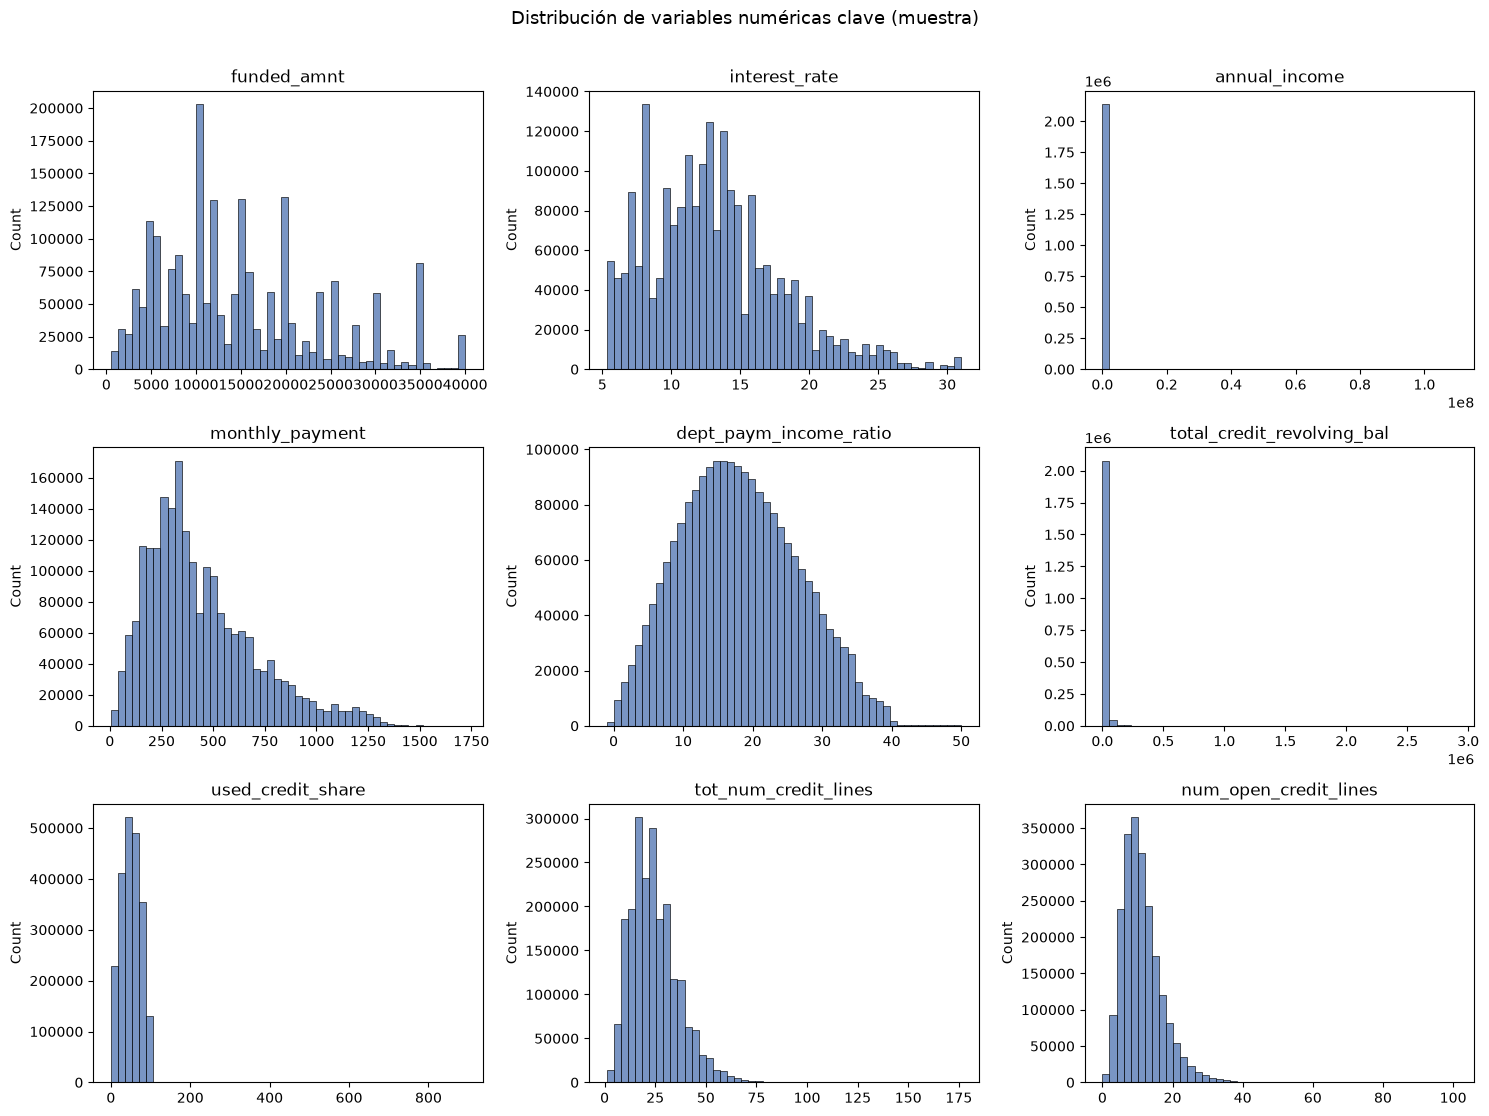

In [10]:
cols_clave = ['funded_amnt', 'interest_rate', 'annual_income', 'monthly_payment',
              'dept_paym_income_ratio', 'total_credit_revolving_bal', 'used_credit_share',
              'tot_num_credit_lines', 'num_open_credit_lines']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, cols_clave):
    sns.histplot(df_orig[col].drop_nulls(), bins=50, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución de variables numéricas clave (muestra)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
df_orig['annual_income', 'total_credit_revolving_bal'].describe()

statistic,annual_income,total_credit_revolving_bal
str,f64,f64
"""count""",2.139643e6,2.139643e6
"""null_count""",0.0,0.0
"""mean""",78987.774254,16654.422991
"""std""",115041.933734,22931.829254
"""min""",1896.0,0.0
"""25%""",47400.0,5985.0
"""50%""",65299.0,11328.0
"""75%""",95000.0,20207.0
"""max""",1.1e8,2.904836e6


In [12]:
df_orig = df_orig.with_columns(
    pl.col("annual_income").log1p().alias("annual_income_log"),
    pl.col("total_credit_revolving_bal").log1p().alias("total_credit_revolving_bal_log")
)

In [13]:
df_orig['annual_income_log', 'total_credit_revolving_bal_log'].describe()

statistic,annual_income_log,total_credit_revolving_bal_log
str,f64,f64
"""count""",2.139643e6,2.139643e6
"""null_count""",0.0,0.0
"""mean""",11.113258,9.204406
"""std""",0.545618,1.246244
"""min""",7.548029,0.0
"""25%""",10.766399,8.697179
"""50%""",11.086747,9.335121
"""75%""",11.461643,9.913834
"""max""",18.515991,14.881888


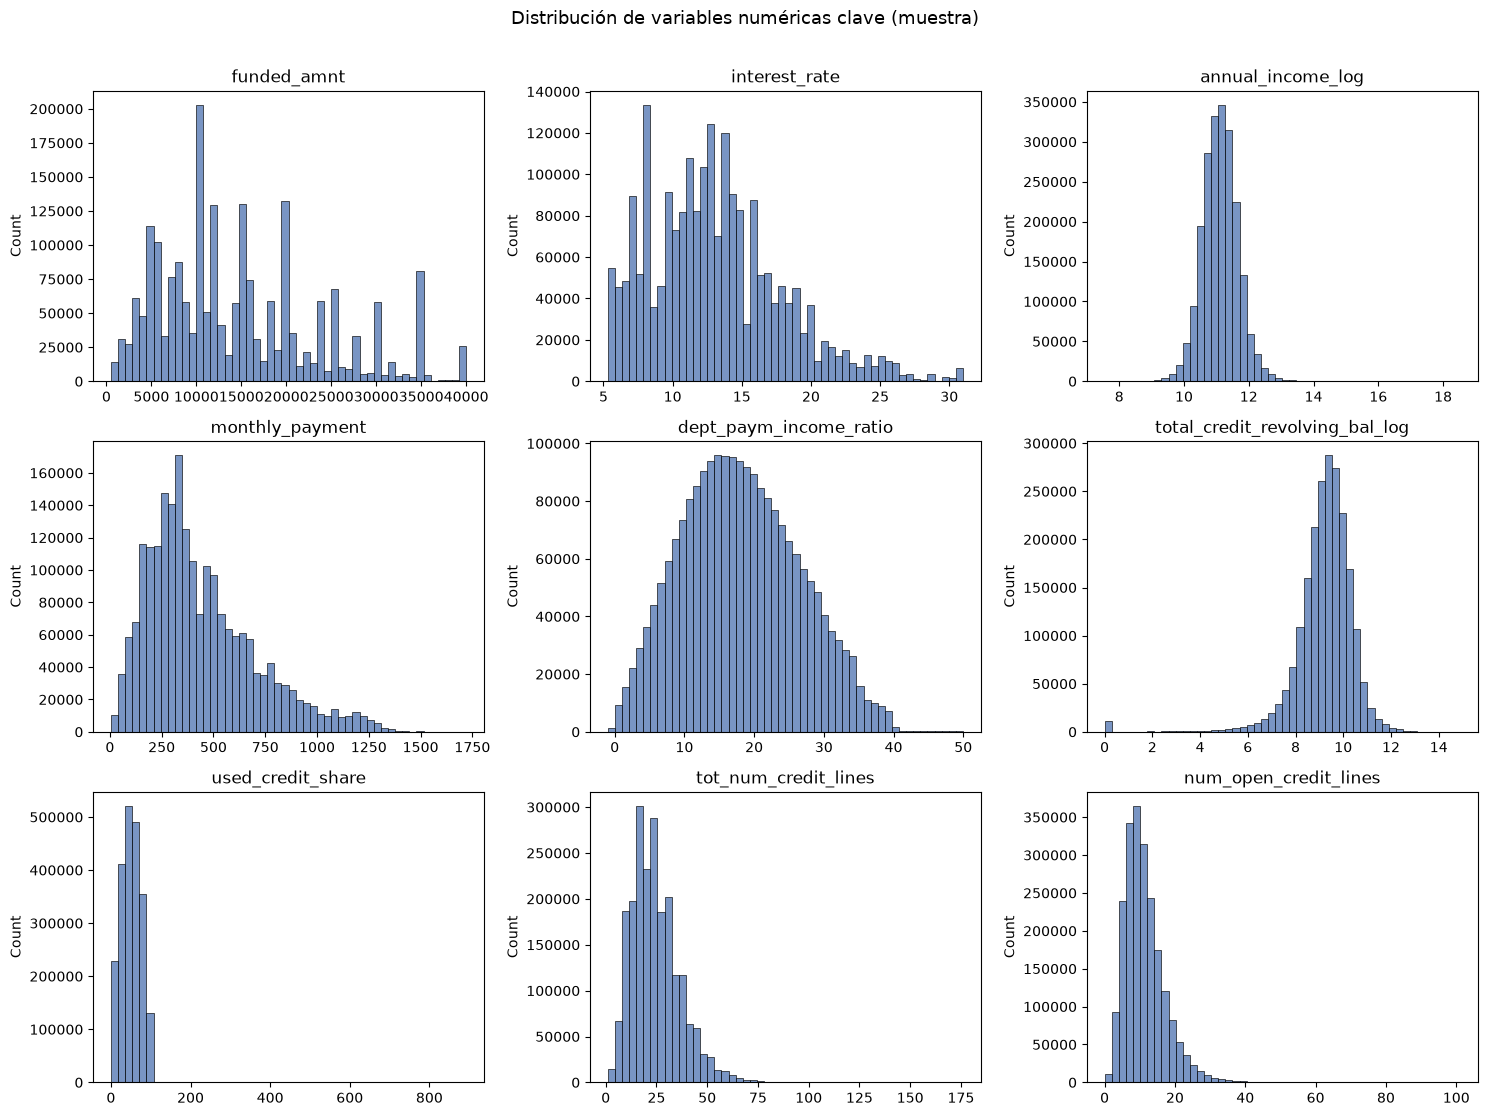

In [14]:
cols_clave = ['funded_amnt', 'interest_rate', 'annual_income_log', 'monthly_payment',
              'dept_paym_income_ratio', 'total_credit_revolving_bal_log', 'used_credit_share',
              'tot_num_credit_lines', 'num_open_credit_lines']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, cols_clave):
    sns.histplot(df_orig[col].drop_nulls(), bins=50, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución de variables numéricas clave (muestra)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

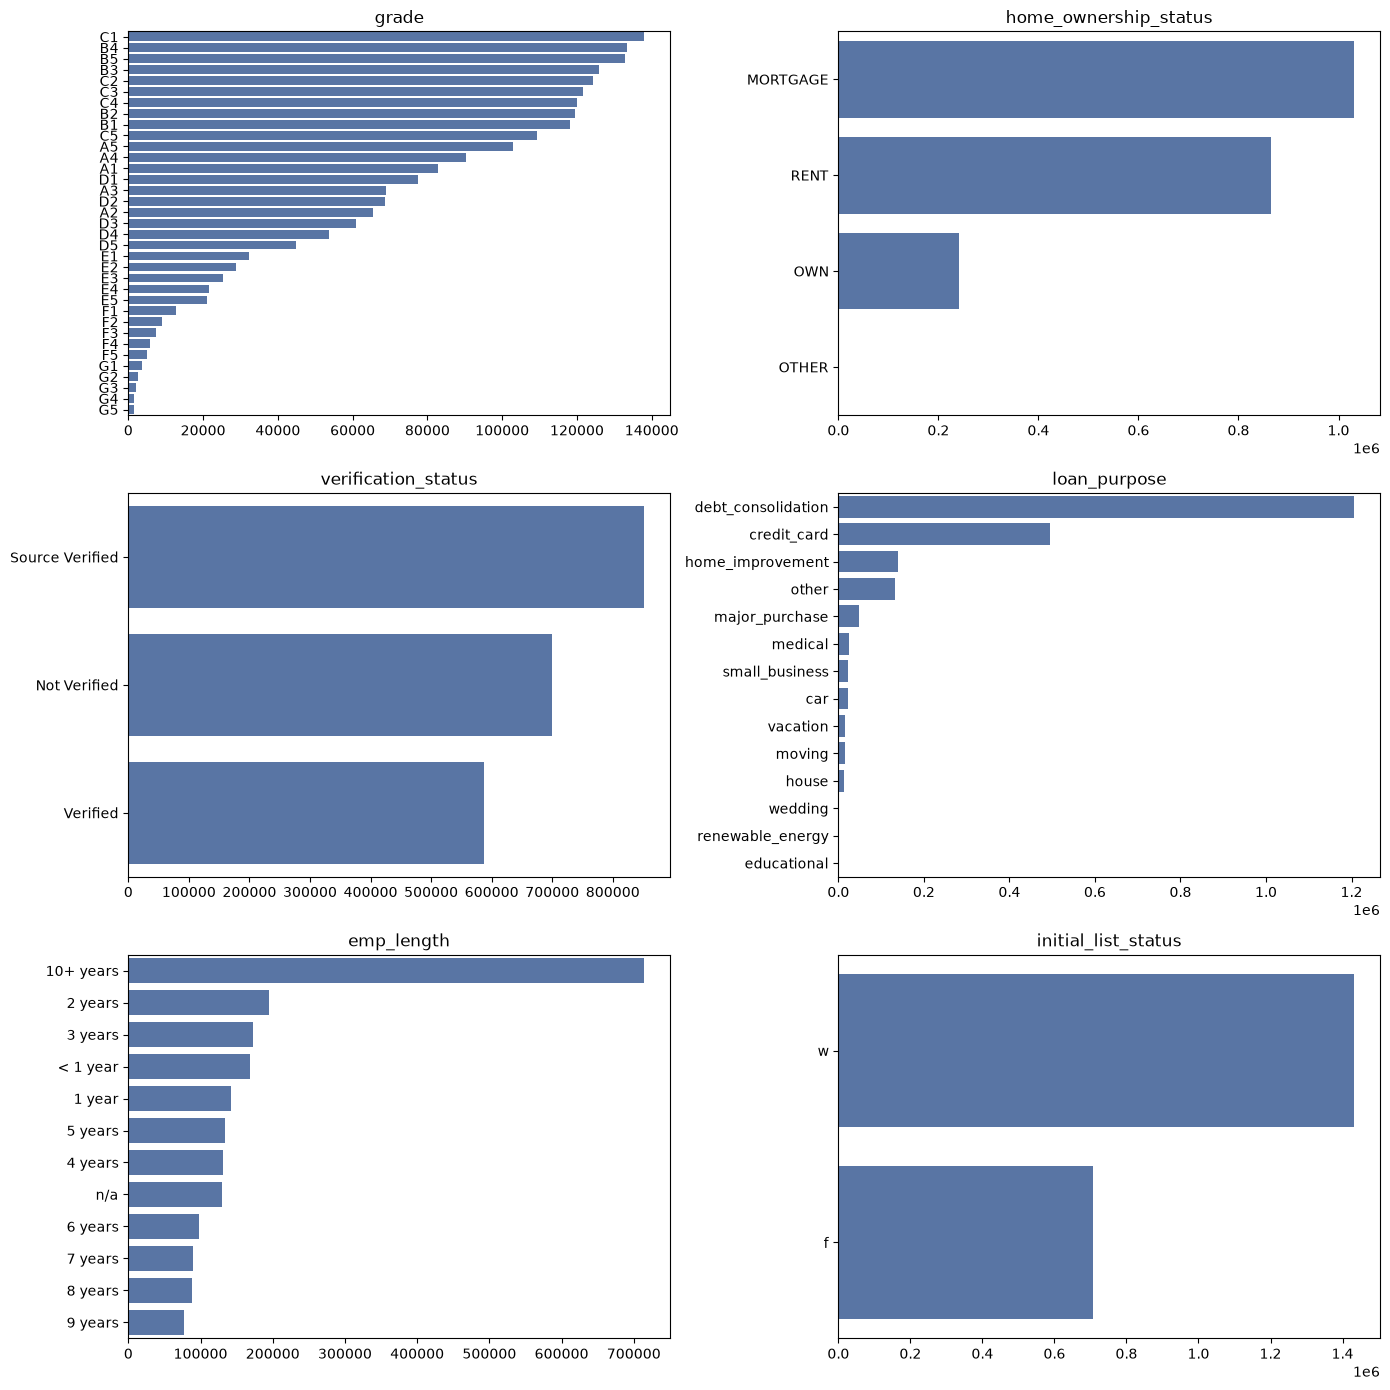

In [15]:
cat_a_graficar = ['grade','home_ownership_status', 'verification_status',
                  'loan_purpose', 'emp_length', 'initial_list_status']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flat, cat_a_graficar):
    # fill_null solo para que la categoría "sin dato" se vea en el gráfico (no modifica df)
    conteo = (df_orig[col].cast(pl.String).fill_null('(sin dato)')
              .value_counts().sort('count', descending=True))
              
    sns.barplot(
        x=conteo['count'].to_list(),
        y=conteo[col].to_list(),
        ax=ax,
        color='#4C72B0'
    )    
    ax.set_title(col)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

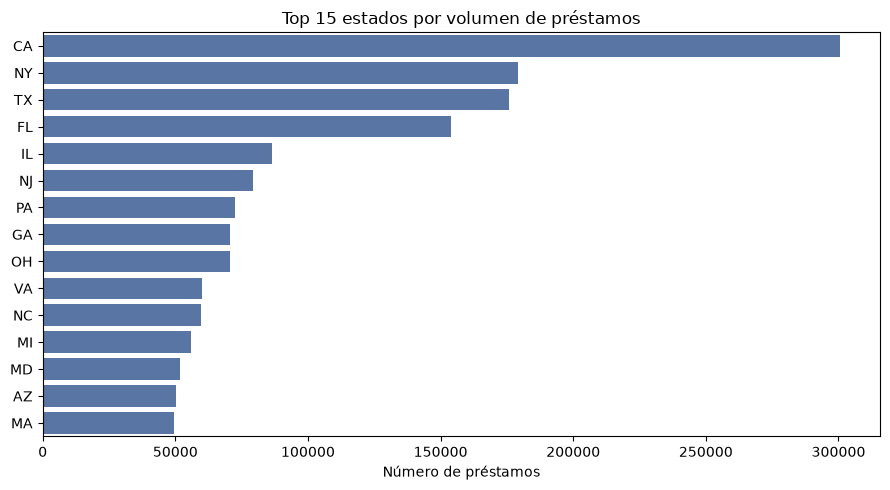

In [16]:
top_estados = (
    df_orig['addr_state']
    .value_counts()
    .sort('count', descending=True)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    x=top_estados['count'].to_list(),
    y=top_estados['addr_state'].to_list(),
    ax=ax,
    color='#4C72B0'
)

ax.set_title('Top 15 estados por volumen de préstamos')
ax.set_xlabel('Número de préstamos')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Análisis de valores faltantes. 

### ~ 40% de valores faltantes.

Todas estas variables tienen ~ 40% de valores faltantes. (`num_open_trades_in_6mths`, `num_installment_acc_op_in_12mths`, `num_installment_acc_op_in_24mths`, `num_rev_trades_op_in_12mths`, `num_rev_trades_op_in_24mths`, `max_bal_owed`, `bal_to_cred_lim`, `num_inq`, `mths_since_last_installment_acc_op`). Se sospecha que podrían tener un patron similar o que podría estar relacionado con la estructura de base de datos.

Empezaremos con una variable de muestra `issue_date_year` y veremos la relación con el tiempo `issue_date_year`

In [51]:
missing_40 = df_orig.group_by('issue_date_year').agg(
    (pl.col('num_open_trades_in_6mths').null_count() / pl.len() * 100)
).sort('issue_date_year')

with pl.Config(tbl_rows = -1, tbl_cols = -1):
    print(missing_40)

shape: (12, 2)
┌─────────────────┬──────────────────────────┐
│ issue_date_year ┆ num_open_trades_in_6mths │
│ ---             ┆ ---                      │
│ i64             ┆ f64                      │
╞═════════════════╪══════════════════════════╡
│ 2007            ┆ 100.0                    │
│ 2008            ┆ 100.0                    │
│ 2009            ┆ 100.0                    │
│ 2010            ┆ 100.0                    │
│ 2011            ┆ 100.0                    │
│ 2012            ┆ 100.0                    │
│ 2013            ┆ 100.0                    │
│ 2014            ┆ 100.0                    │
│ 2015            ┆ 94.957568                │
│ 2016            ┆ 0.014334                 │
│ 2017            ┆ 0.0                      │
│ 2018            ┆ 0.0                      │
└─────────────────┴──────────────────────────┘



Como podemos ver, los datos faltantes vienen antes del año 2016. Es decir, antes de esa fecha no se registraba este tipo de datos. Ahora haremos un for y veremos tienen el mismo patron el resto de variables. 

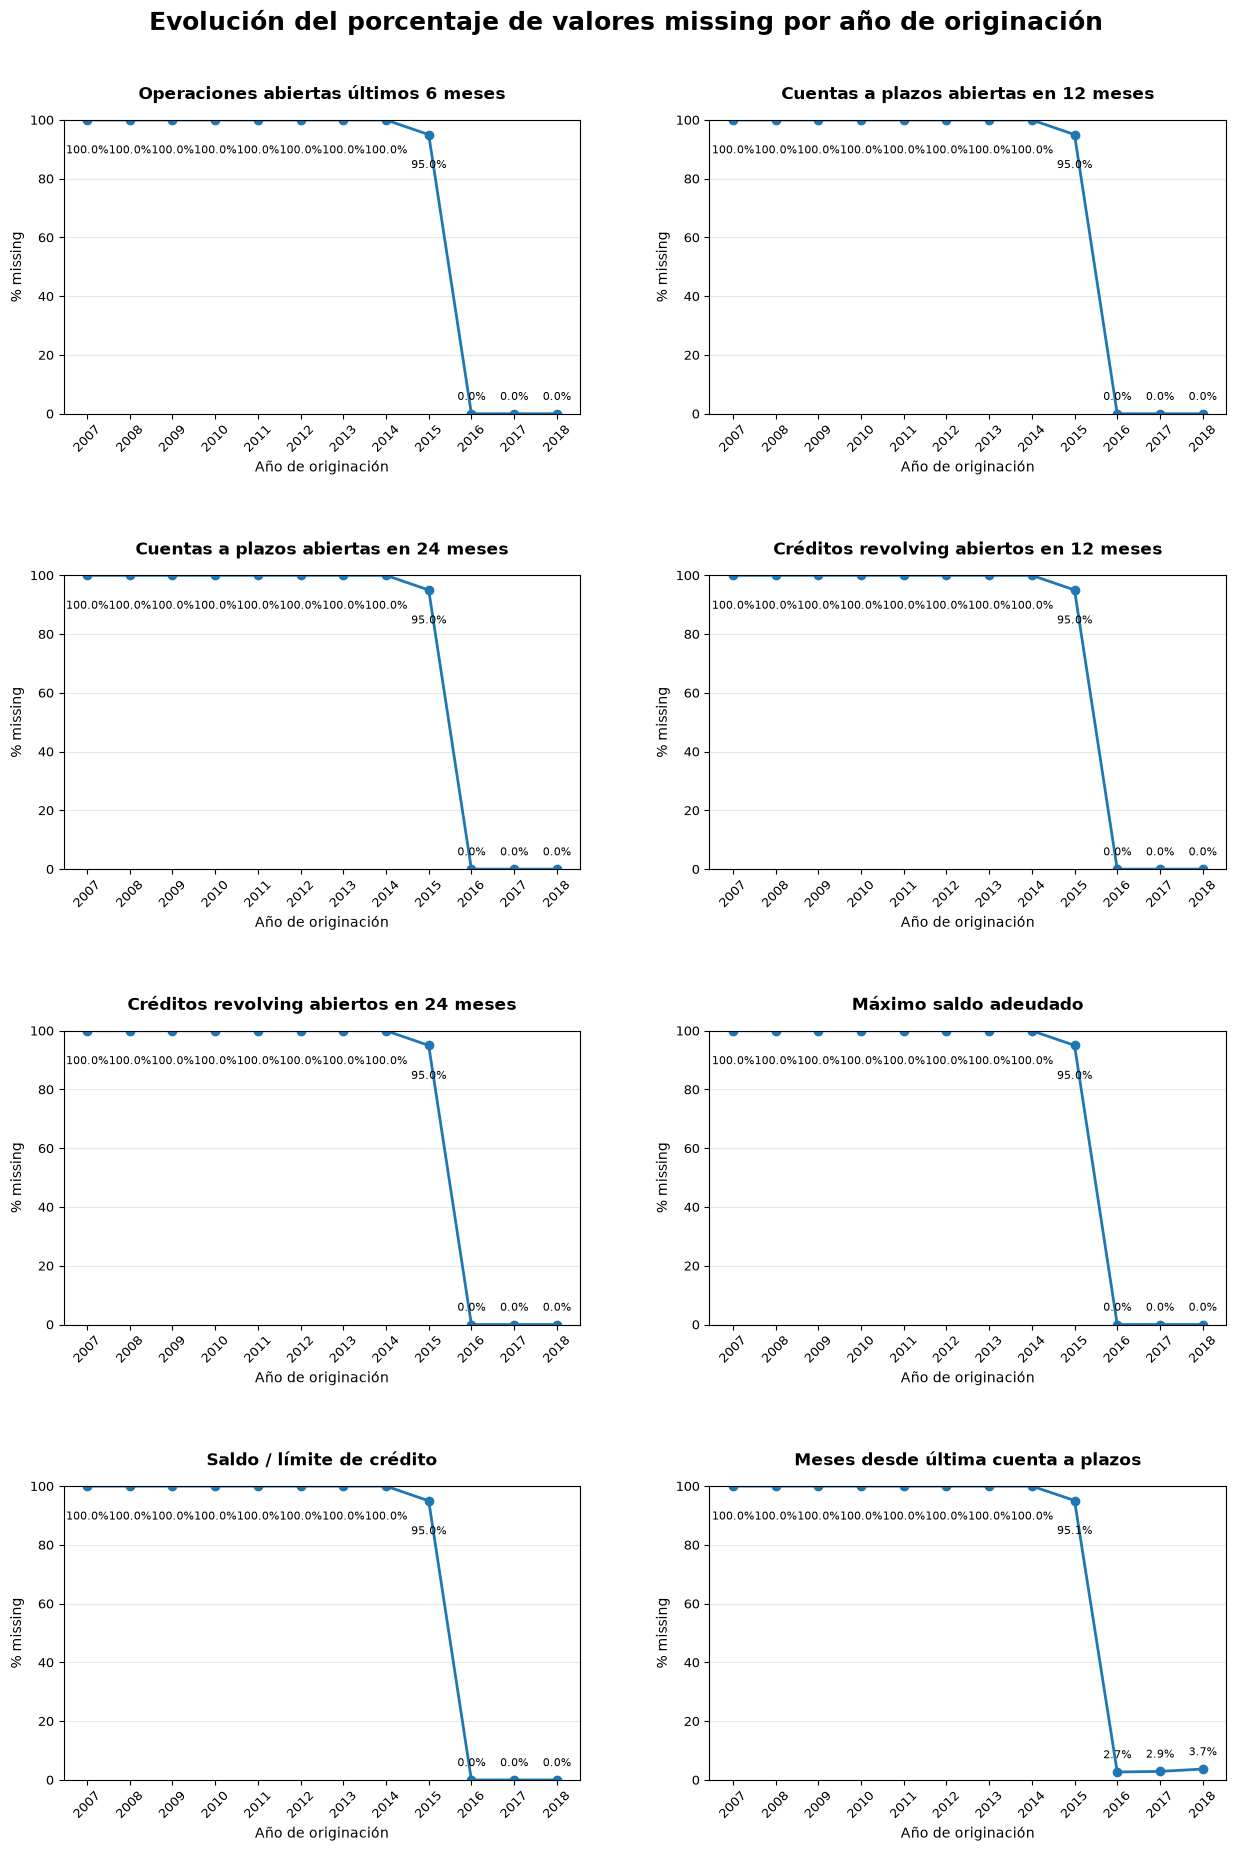

In [ ]:
import matplotlib.pyplot as plt

nombres_grafico = {
    'num_open_trades_in_6mths': 'Operaciones abiertas últimos 6 meses',
    'num_installment_acc_op_in_12mths': 'Cuentas a plazos abiertas en 12 meses',
    'num_installment_acc_op_in_24mths': 'Cuentas a plazos abiertas en 24 meses',
    'num_rev_trades_op_in_12mths': 'Créditos revolving abiertos en 12 meses',
    'num_rev_trades_op_in_24mths': 'Créditos revolving abiertos en 24 meses',
    'max_bal_owed': 'Máximo saldo adeudado',
    'bal_to_cred_lim': 'Saldo / límite de crédito',
    'mths_since_last_installment_acc_op': 'Meses desde última cuenta a plazos'
}

fig, axes = plt.subplots(nrows=4,ncols=2,figsize=(15, 20))

for ax, col in zip(axes.flat, missing_40):

    resultado = (
        df_orig
        .group_by('issue_date_year')
        .agg((pl.col(col).null_count() / pl.len() * 100)
            .round(1)
            .alias('pct_missing')
        )
        .sort('issue_date_year')
    )

    años = resultado['issue_date_year'].cast(pl.String).to_list()
    pct_missing = resultado['pct_missing'].to_list()

    # Línea
    ax.plot(años,pct_missing,marker='o',linewidth=2)

    # Porcentaje dentro del área del gráfico
    for x, y in zip(años, pct_missing):

        # Si el punto está muy arriba, colocamos el texto debajo
        if y > 85:
            offset = -18
            va = 'top'
        else:
            offset = 8
            va = 'bottom'

        ax.annotate(
            f'{y:.1f}%',
            (x, y),
            textcoords='offset points',
            xytext=(0, offset),
            ha='center',
            va=va,
            fontsize=8
        )

    # Título
    ax.set_title(
        nombres_grafico[col],
        fontsize=12,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel(
        'Año de originación',
        fontsize=10
    )

    ax.set_ylabel(
        '% missing',
        fontsize=10
    )

    ax.set_ylim(0, 100)

    ax.tick_params(
        axis='x',
        rotation=45,
        labelsize=9
    )

    ax.tick_params(
        axis='y',
        labelsize=9
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

# Título general
fig.suptitle(
    'Evolución del porcentaje de valores missing por año de originación',
    fontsize=18,
    fontweight='bold',
    y=0.995
)

# Más espacio vertical entre los gráficos
plt.subplots_adjust(
    top=0.94,
    hspace=0.55,
    wspace=0.25
)

plt.show()

Como se puede observar, todos tienen el mismo patron de valores faltantes antes del 2016. Ahora, ¿que tipo de tratamiento merece estas de variables? - En primer lugar, este tipo de variables depende de la variable `issue_date_year`, por lo tanto es un tratamiento tipo **Missing at Random**. Una forma de imputación sería:

1. En primer lugar crear una variable indicadora, que nos diga si anteriormente habia un dato faltante o no. 
2. En segundo lugar, aplicar una mediana global. 

In [18]:
df_orig.select(
    pl.col('mths_since_recent_bankcard_delinq').is_null().sum().alias("nulls"),
    (pl.col("mths_since_recent_bankcard_delinq") == 0).sum().alias("zeros"),
    pl.col('mths_since_recent_bankcard_delinq').is_not_null().sum().alias("no_nulls"),

)

nulls,zeros,no_nulls
u32,u32,u32
1643502,778,496141


In [19]:
df_orig.group_by(
    pl.when(pl.col("mths_since_recent_bankcard_delinq").is_null())
    .then(pl.lit("NULL"))
    .when(pl.col("mths_since_recent_bankcard_delinq")==0)
    .then(pl.lit("ZERO"))
    .otherwise(pl.lit("VALOR"))
    .alias("tipo")
).agg(
    pl.col("y").mean().alias("default_rate"),
    pl.len().alias("count")
).sort("default_rate", descending=True)

tipo,default_rate,count
str,f64,u32
"""ZERO""",0.145244,778
"""VALOR""",0.14122,495363
"""NULL""",0.127562,1643502


### Mese desde la ultima incidencia 

Las siguientes variables tiene un comportamiento distinto, son de tipo historial de crédito, el dato puede faltar simplemente porque el cliente **nunca ha tenido** esa incidencia -  `mths_since_last_delinq`, `mths_since_recent_bankcard_delinq`, `mths_since_recent_revol_delinq`

In [56]:
missing_grup2 = (
    df_orig.group_by('issue_date_year')
    .agg((pl.col('mths_since_last_delinq').null_count() / pl.len() * 100).round(1).alias('pct_missing'))
    .sort('issue_date_year')
)

with pl.Config(tbl_rows = -1, tbl_cols = -1):
    print(missing_grup2)

shape: (12, 2)
┌─────────────────┬─────────────┐
│ issue_date_year ┆ pct_missing │
│ ---             ┆ ---         │
│ i64             ┆ f64         │
╞═════════════════╪═════════════╡
│ 2007            ┆ 1.7         │
│ 2008            ┆ 38.1        │
│ 2009            ┆ 67.0        │
│ 2010            ┆ 64.3        │
│ 2011            ┆ 66.2        │
│ 2012            ┆ 58.8        │
│ 2013            ┆ 56.5        │
│ 2014            ┆ 49.2        │
│ 2015            ┆ 48.4        │
│ 2016            ┆ 47.2        │
│ 2017            ┆ 49.8        │
│ 2018            ┆ 55.5        │
└─────────────────┴─────────────┘


Como podemos ver, los valores faltantes de la variable de muestra `mths_since_last_delinq` no dependen de `issue_date_year`, tienen un comportamiento distinto. Es un caso tipo de **Missing not at random** (MNAR). El dato faltante en si es un indicador del buen historial del cliente. 

El probable tratamiento a seguir seria:

1. Crear una variable flag (1,0) para determinar si ese valor era faltante o no antes de la imputación.
2. Reemplazar los nulls con un valor semilla o centinela. 

In [20]:
df_orig.select(
    pl.col("mths_since_last_delinq").is_null().sum().alias("nulls"),
    (pl.col("mths_since_last_delinq") == 0).sum().alias("zeros")
)

nulls,zeros
u32,u32
1090997,2595


In [ ]:
#

In [21]:
df_orig.group_by(
    pl.when(pl.col("mths_since_last_delinq").is_null())
      .then(pl.lit("NULL"))
      .when(pl.col("mths_since_last_delinq") == 0)
      .then(pl.lit("ZERO"))
      .otherwise(pl.lit("VALOR"))
      .alias("tipo")
).agg(
    pl.col("y").mean().alias("default_rate"),
    pl.len().alias("count")
).sort("default_rate", descending=True)

tipo,default_rate,count
str,f64,u32
"""ZERO""",0.182274,2595
"""VALOR""",0.13743,1046051
"""NULL""",0.124184,1090997


In [22]:
df_orig.group_by(['home_ownership_status']).agg(
    pl.col('y').mean().alias('default_rate'),
    pl.col('y').count().alias('count'),
).sort('default_rate', descending=True)

home_ownership_status,default_rate,count
str,f64,u32
"""RENT""",0.15015,865430
"""OWN""",0.129376,241591
"""MORTGAGE""",0.114798,1031398
"""OTHER""",0.093137,1224


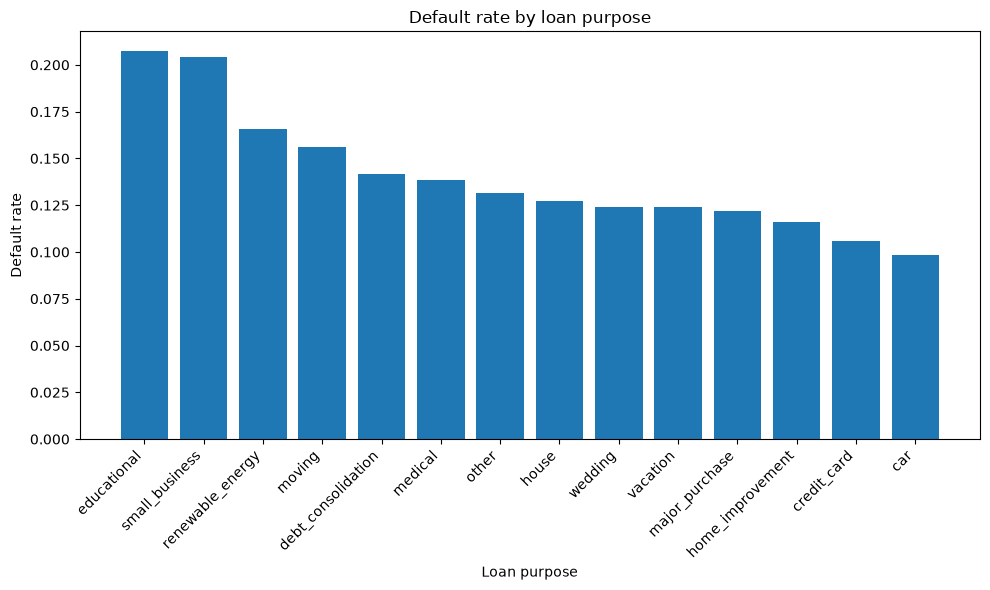

In [23]:
loan_purpose = df_orig.group_by(['loan_purpose']).agg(
    pl.col('y').mean().alias('default_rate'),
    pl.col('y').count().alias('count'),
).sort('default_rate', descending=True)

plt.figure(figsize=(10, 6))

plt.bar(
    loan_purpose["loan_purpose"],
    loan_purpose["default_rate"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("Loan purpose")
plt.title("Default rate by loan purpose")

plt.tight_layout()
plt.show()

In [24]:
df_orig.group_by(['num_30+_delinq_in_2yrs']).agg(
    pl.col('y').mean().alias('default_rate'),
    pl.col('y').count().alias('count'),
).sort('default_rate', descending=True)


num_30+_delinq_in_2yrs,default_rate,count
i64,f64,u32
27,1.0,1
36,1.0,1
25,0.5,2
19,0.25,20
16,0.235294,51
…,…,…
29,0.0,2
26,0.0,3
23,0.0,2
